# Heat flow with a boundary constraint: a small LCHS example

A short rod has cold ends and a heater near its center. Schleich, Kharazi, Li and coauthors (arXiv:2506.21751v1) hold such boundary values in quantum algorithms for differential equations with an imaginary penalty.

This notebook solves the penalized heat equation on four grid points with NWQLib's Linear Combination of Hamiltonian Simulations (LCHS). It separates the error of the finite penalty, measured against exact cold ends, from the error of LCHS, measured against the penalized equation it solves.

Install with `python -m pip install -e ".[aer,notebook]"` from the repository root · one 10-qubit circuit · about 20 s on a laptop.

> **How to read this notebook.** The next cells solve the rod and show the answer with its cost.
>
> - Sections 1 to 5: will it run, what it costs, how accurate, how large, what it assumes
> - Section 6: what NWQLib adds
> - Sections 7 to 9: the paper's model, with the rod, the imaginary penalty and LCHS
> - Appendix A to E: input scales, weighted branches, the resource estimate, a reference check, which run produced these temperatures

In [1]:
from time import perf_counter

import numpy as np

from nwqlib import LinearDynamics, Solution, plan, solve
from nwqlib.algorithms import LCHS

N = 4                # grid points. The exact-boundary reference of Section 3 assumes exactly two interior points.
D = 4.0              # diffusion coefficient of the paper's heat experiments (arXiv:2506.21751v1, caption of Figure 5)
FINAL_TIME = 0.005   # D T / h² = 0.18, so the initial bump keeps most of its amplitude (Section 7)
PENALTY = 1000.0     # lambda T = 5 radians. The penalty error and the LCHS error are then of similar size.
SOURCE_RATE = 298.0  # point-source strength of the paper's heat experiments (arXiv:2506.21751v1, Section III.2.1)
K_QUBITS = 5         # 32 k nodes, which the initial state and 4 source times turn into 32 + 4 * 32 = 160 branches on 8 address qubits
DUHAMEL_NODES = 4    # Gauss nodes of the source-time integral

coordinates = np.linspace(0.0, 1.0, N)
h = coordinates[1] - coordinates[0]
boundary = np.array([True, False, False, True])
interior = np.flatnonzero(~boundary)
initial = np.exp(-((coordinates - 0.5) / 0.25) ** 2)  # a smooth central bump
initial[boundary] = 0.0                                 # with cold ends at the start
source = np.array([0.0, 0.0, SOURCE_RATE, 0.0])         # continuous heating at x = 2/3

# Periodic heat generator B0 plus the imaginary endpoint penalty (Section 8). NWQLib solves dv/dt = -A v + f.
shift = np.roll(np.eye(N), 1, axis=0)
B0 = D * (shift + shift.T - 2.0 * np.eye(N)) / h**2  # D times the periodic Laplacian
Pc = np.diag(boundary.astype(float))                 # projector onto the two ends
L, H = -B0, PENALTY * Pc
A = L + 1j * H

started = perf_counter()
problem = LinearDynamics(A=A, initial_state=initial, source=source, time=FINAL_TIME)
method = LCHS(
    lchs_kernel={"implementation": "near_optimal_eq7", "parameters": {"beta": 0.9}},  # near-optimal kernel of An, Childs and Lin, arXiv:2312.03916v2 (notebook Section 9)
    k_quadrature={"implementation": "signed_binary_uniform",   # 2**K_QUBITS uniform k nodes of spacing 1/2
                  "parameters": {"num_qubits": K_QUBITS, "lsb_position": -1}},
    approximation_tolerance=0.01,                   # does not refine this explicit k grid (Section 9)
    hamiltonian_evolution_backend="dense_exact",    # each branch is an exact 4 × 4 matrix exponential
    lcu_select_implementation="branch_controlled",  # each branch evolution is controlled on its address
    duhamel_nodes=DUHAMEL_NODES,
    make_l_psd=False,                               # L is already positive semidefinite, so no shift is added
)
selected = plan(problem, method=method, output=Solution(), seed=11)  # selects the construction, runs no circuit
result = solve(selected, progress=False)                             # builds and simulates the circuit
seconds = perf_counter() - started
v_lchs = np.asarray(result.solution)                                 # temperatures with their scale and phase

In [2]:
# Display helpers for tables, figures and the result card. They format values read from the records
# passed to them and run no plan or solve.
from html import escape

import matplotlib.pyplot as plt
from IPython.display import HTML, display

plt.rcParams.update({"figure.dpi": 110, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})


def format_value(value, digits=3):
    """Round only the display to ``digits`` significant digits. Calculations and saved records keep full precision."""
    if value is None:
        return "unavailable"
    if isinstance(value, (bool, np.bool_)):
        return str(value)
    if isinstance(value, (int, np.integer)):
        return f"{value:,}"
    if isinstance(value, (float, np.floating)):
        return f"{value:.{digits}g}"
    if isinstance(value, (complex, np.complexfloating)):
        return f"{value.real:.{digits}g}{value.imag:+.{digits}g}i"
    if isinstance(value, (tuple, list)):
        return ", ".join(format_value(item, digits) for item in value)
    return str(value)


def format_bytes(count):
    """Show a byte count in bytes and in megabytes."""
    return f"{count:,} bytes" + (f" ({count / 1e6:.3g} MB)" if count >= 1e6 else "")


def show_table(rows, headers=("Quantity", "Value", "Meaning"), *, digits=3, details=None):
    """Display rows of computed values, optionally collapsed under a summary line."""
    heading = "".join("<th>" + escape(label) + "</th>" for label in headers)
    body = "".join("<tr>" + "".join(
        '<td style="overflow-wrap:anywhere">' + escape(format_value(value, digits)) + "</td>"
        for value in row) + "</tr>" for row in rows)
    table = ('<table style="width:100%;table-layout:fixed"><thead><tr>'
             + heading + "</tr></thead><tbody>" + body + "</tbody></table>")
    if details is not None:
        table = "<details><summary>" + escape(details) + "</summary>" + table + "</details>"
    display(HTML(table))


def fact_value(fact):
    """Read a recorded scalar, preserving unavailable values."""
    value = fact.value
    if value is None or isinstance(value, (bool, int, float)):
        return value
    if hasattr(value, "numerator"):
        return value.numerator if value.denominator == 1 else value.numerator / value.denominator
    return value.value


def show_card(result, coordinates, initial, v_penalty, u_dirichlet, predicted, seconds):
    """Show the result card: the verdict with its key numbers and cost, the comparison figure and what NWQLib did."""
    rec = result.plan.reconstruction
    v_lchs = np.asarray(result.solution)
    algorithm_error = np.linalg.norm(v_lchs - v_penalty)
    penalty_error = np.linalg.norm(v_penalty - u_dirichlet)
    combined = np.linalg.norm(v_lchs - u_dirichlet) / np.linalg.norm(u_dirichlet)
    if penalty_error > algorithm_error:
        verdict = (f"The finite penalty moves the temperatures by {penalty_error:.2g} from the exact-boundary "
                   f"reference, more than LCHS moves them from the penalized equation it solves, "
                   f"{algorithm_error:.2g}. A more accurate LCHS solve alone would therefore not remove the main error.")
    elif penalty_error < algorithm_error:
        verdict = (f"LCHS moves the temperatures by {algorithm_error:.2g} from the penalized equation it solves, "
                   f"more than the finite penalty moves them from the exact-boundary reference, "
                   f"{penalty_error:.2g}. The LCHS approximation is therefore the larger error for this selection.")
    else:
        verdict = (f"The finite penalty and LCHS move the temperatures by the same L2 distance, "
                   f"{penalty_error:.2g}.")
    width = len(rec.system_bits) + len(rec.success_bits)
    shots = fact_value(predicted.quantity("shots").fact)
    display(HTML(
        f"<p><strong>Result.</strong> {verdict} Both numbers are absolute L2 errors in temperature units. The LCHS "
        f"temperatures differ from the exact-boundary reference by {combined:.1%} in relative L2 norm. "
        f"Execution: <code>{result.data.receipts[0].target.name}</code> simulator, exact readout of every amplitude "
        f"of one {width}-qubit circuit. Output: <code>result.solution</code>, the temperatures with their physical "
        f"scale and phase. The left panel shows their real part, and Section 3 the imaginary part.</p>"
        f"<p><strong>Cost.</strong> Quantum: {width} qubits, "
        f"{format_value(fact_value(predicted.quantity('cx').fact))} CX gates predicted before building (an upper "
        f"bound for this circuit, Section 2), {'no shots (exact readout)' if shots == 0 else f'{shots:,} shots'}. "
        f"Classical: {format_bytes(fact_value(predicted.quantity('known_memory', location='host').fact))} of "
        f"host arrays predicted before building (not the process peak), planning work "
        f"{result.data.trace.construction_work_reserved:,} units (a planning quantity, not seconds), "
        f"{seconds:.1f} s for plan and solve on this computer.</p>"))

    fig, axes = plt.subplots(1, 2, figsize=(11.4, 3.8), layout="constrained")
    for values, label, style in ((initial, "Initial", "o:"),
                                 (u_dirichlet, "Exact-boundary reference", "o-"),
                                 (v_penalty.real, "Penalty reference: real part", "s--"),
                                 (v_lchs.real, "LCHS: real part", "x-.")):
        axes[0].plot(coordinates, values, style, label=label)
    axes[0].set(xlabel="Position x", ylabel="Temperature (real part)", title="Final real parts and the initial temperature")
    axes[0].legend(fontsize=8)
    axes[1].bar(("LCHS approximation", "Finite penalty", "Combined"),
                (algorithm_error, penalty_error, np.linalg.norm(v_lchs - u_dirichlet)),
                color=("#0072B2", "#E69F00", "#009E73"))
    axes[1].set(ylabel="Absolute complex L2 error", title="Which approximation contributes the error?", ylim=(0, None))
    plt.show()

    nodes = rec.physical_branches // (1 + len(rec.source_nodes))
    steps = (
        "Checked numerically that the Hermitian part L of A has no negative eigenvalue, which the LCHS "
        "representation requires, so no shift was added.",
        f"Computed the complex kernel weights on {nodes} k nodes and combined them with the initial state and "
        f"{len(rec.source_nodes)} Gauss source-time nodes into {rec.physical_branches} weighted branches "
        f"e<sup>−i(kL+H)t</sup>, addressed by {len(rec.success_bits)} qubits, with normalization "
        f"α = {rec.coefficient_l1_norm:.3g}.",
        f"Exponentiated the {rec.dimension} × {rec.dimension} Hamiltonian of each branch, built the circuit that "
        f"prepares the weights, applies the branches and reverses the preparation, and simulated it on the Aer "
        f"statevector simulator.",
        f"Kept the outcome in which all address qubits read zero and multiplied it by "
        f"α = {rec.recovery.as_float():.3g}, so <code>result.solution</code> holds the temperatures with their "
        f"scale and phase.",
    )
    display(HTML("<p><strong>What NWQLib did for you.</strong></p><ol>"
                 + "".join(f"<li>{step}</li>" for step in steps) + "</ol>"))

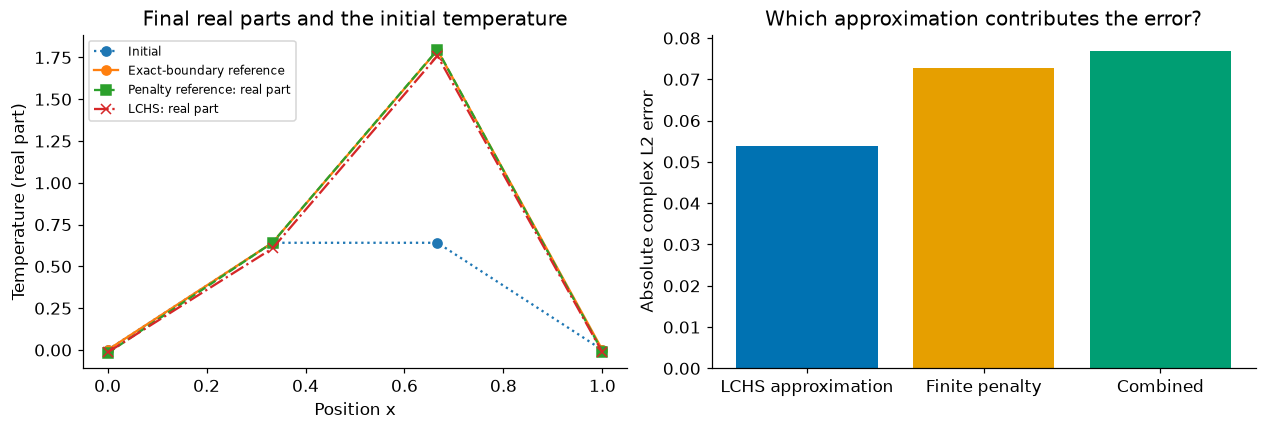

In [3]:
from scipy.linalg import expm

from nwqlib import estimate
from nwqlib.resources import ResourceContext

# Two classical references (Section 3). The penalty reference solves the penalized equation with the source as a fifth coordinate that stays 1.
augmented = np.zeros((N + 1, N + 1), dtype=complex)
augmented[:N, :N] = -A
augmented[:N, N] = source
v_penalty = (expm(FINAL_TIME * augmented) @ np.r_[initial, 1.0])[:N]
# The exact-boundary reference. Its symmetric and antisymmetric interior modes decay at D/h² and 3D/h² under a constant source.
modes = np.array([[1.0, 1.0], [1.0, -1.0]]) / np.sqrt(2.0)
decay_rates = (D / h**2) * np.array([1.0, 3.0])
mode_initial = modes.T @ initial[interior]
mode_source = modes.T @ source[interior]
source_integral = -np.expm1(-decay_rates * FINAL_TIME) / decay_rates
u_dirichlet = np.zeros(N)
u_dirichlet[interior] = modes @ (np.exp(-decay_rates * FINAL_TIME) * mode_initial + source_integral * mode_source)

algorithm_error = np.linalg.norm(v_lchs - v_penalty)     # LCHS against the equation it solves
penalty_error = np.linalg.norm(v_penalty - u_dirichlet)  # penalty reference against the exact-boundary reference
combined_error = np.linalg.norm(v_lchs - u_dirichlet)
predicted = estimate(selected, context=ResourceContext(basis="cx"))  # counts from the resource laws, no circuit built
show_card(result, coordinates, initial, v_penalty, u_dirichlet, predicted, seconds)

**Your own model.** NWQLib receives $A$, the initial vector and the source. The rod, the penalty and both references are this notebook's own model code, fixed at `N = 4`. The [LCHS introduction](lchs_linear_dynamics_intro.ipynb) has a template cell for your own generator, initial state and final time.

## 1. Will it run?

**`plan` checks the premise of LCHS and reports the circuit width before anything is built.**

- **Equation and sign.** NWQLib solves $\dot v=-Av+f$, so a heat generator $B$ enters as $A=-B$. The source is constant in time.
- **Premise.** The Hermitian part $L$ of $A$ must have no negative eigenvalue. Here it has none, so no shift is added (`make_l_psd=False`).
- **Size.** Two system qubits hold the four temperatures, and an address register labels the weighted branches. Section 4 lists the width and the address qubits.
- **Output.** `result.solution` holds the complex temperatures with scale and phase, from exact simulator readout.

## 2. What it costs

**`estimate` gives qubits, CX gates, host memory and planning work before the circuit exists. The run adds the compiled counts, the recorded work and the time.** On a quantum computer, the number of two-qubit CX gates and the circuit depth set its cost before any error correction.

`estimate` counts, for each branch, the gates of the exact synthesis of its $4\times4$ evolution and input preparation, priced at Qiskit's count once the eight address controls are added. `prepare` builds the circuit, and `inspect_resources` compiles a copy with Qiskit. The line under the table gives the time both took.

In [4]:
from nwqlib import prepare

rec = selected.reconstruction
total_qubits = len(rec.system_bits) + len(rec.success_bits)
cx_law = fact_value(predicted.quantity("cx").fact)
compile_started = perf_counter()
prepared = prepare(selected, progress=False)
with prepared.run:  # the prepared Run holds the circuit until the block ends
    compiled = prepared.inspect_resources(
        max_operations=10_000_000,  # the circuit has more operations than the default cap of 100,000
        transpile_options={"basis_gates": ["cx", "u"], "optimization_level": 1, "seed_transpiler": 7})
compile_seconds = perf_counter() - compile_started
compiled_cx = compiled["operations"].get("cx", 0)
show_table([
    ("Qubits", fact_value(predicted.quantity("logical_width", location="logical_device").fact), compiled["num_qubits"]),
    ("CX gates", cx_law, compiled_cx),
    ("Shots", fact_value(predicted.quantity("shots").fact), "None: exact readout"),
    ("Single-qubit gates", "not predicted", compiled["operations"].get("u", 0)),
    ("Depth", "not predicted", compiled["depth"]),
    ("T gates", "not predicted", "Not in the cx and u basis"),
], headers=("Quantum ledger", "Predicted by estimate", "Compiled circuit"))
print(f"Predicted CX is an upper bound for this circuit, {cx_law / compiled_cx:.2f} × the compiled count "
      f"(Qiskit optimization level 1, {compile_seconds:.0f} s to build and compile). "
      f"Compiled CX per weighted branch: {round(compiled_cx / rec.physical_branches):,} over {rec.physical_branches} branches.")

Quantum ledger,Predicted by estimate,Compiled circuit
Qubits,10,10
CX gates,"1,322,108","622,076"
Shots,0,None: exact readout
Single-qubit gates,not predicted,"710,778"
Depth,not predicted,"960,666"
T gates,not predicted,Not in the cx and u basis


Predicted CX is an upper bound for this circuit, 2.13 × the compiled count (Qiskit optimization level 1, 9 s to build and compile). Compiled CX per weighted branch: 3,888 over 160 branches.


In [5]:
trace = result.data.trace
show_table([
    ("Host memory", format_bytes(fact_value(predicted.quantity("known_memory", location="host").fact)),
     "Not measured here"),
    ("Work [units, a planning quantity, not seconds]",
     fact_value(predicted.quantity("construction_work").fact), trace.construction_work_reserved),
    ("Stored run data", "Not predicted", format_bytes(trace.data_bytes)),
    ("Time on this computer", "Not predicted", f"{seconds:.1f} s for plan and solve, "
     f"{sum(event.timing.seconds for event in trace.events):.1f} s of it in the simulator call"),
], headers=("Classical ledger", "Before the run", "Measured or recorded by the run"))

Classical ledger,Before the run,Measured or recorded by the run
Host memory,"111,646,720 bytes (112 MB)",Not measured here
"Work [units, a planning quantity, not seconds]","20,217,728","40,435,456"
Stored run data,Not predicted,"78,189 bytes"
Time on this computer,Not predicted,"8.1 s for plan and solve, 5.1 s of it in the simulator call"


- **Host memory** counts the arrays and payloads the construction declares at the same time. It is not the process peak memory and leaves out native workspace, such as Aer's.
- **Work.** `estimate` counts the unique selected definitions and host bindings, an upper bound. The run records the work it reserved, a different population.
- **Upper bound.** The formula prices every controlled gate of each branch separately, so it lies above the compiled count. Almost all gates sit in SELECT, the step that applies the branch each address selects.
- **Not estimated:** physical qubits, error correction, run time on hardware and price.

## 3. How accurate?

**Each error is measured against an independent classical reference, and the bounds LCHS could state are unavailable for this grid.** The two references answer different questions.

- The **penalty reference** $v_\lambda$ solves the same four-coordinate penalized equation with one classical $5\times5$ matrix exponential, independent of the LCHS quadrature.
- The **exact-boundary reference** $u_D$ holds both endpoints exactly at zero and evolves the two interior temperatures analytically.

<details><summary>How the two references are computed</summary>

A constant source can be incorporated by adding a fifth coordinate that stays equal to 1:

$$\exp\!\left(T\begin{bmatrix}-A&f\\0&0\end{bmatrix}\right)\begin{bmatrix}v(0)\\1\end{bmatrix}=\begin{bmatrix}v_\lambda(T)\\1\end{bmatrix}.$$

This gives the penalty reference $v_\lambda(T)$ for the same finite penalized equation.

With both endpoints held exactly at zero, the two interior coordinates obey $\dot u_I=B_Du_I+f_I$, where

$$B_D=\frac{D}{h^2}\begin{bmatrix}-2&1\\1&-2\end{bmatrix}.$$

The symmetric pattern $(1,1)/\sqrt2$ decays at rate $D/h^2$, while the antisymmetric pattern $(1,-1)/\sqrt2$ decays at rate $3D/h^2$. In either pattern, an initial coefficient $a$ and constant source coefficient $b$ give $ae^{-\gamma T}+b(1-e^{-\gamma T})/\gamma$. This gives the exact-boundary reference analytically.

</details>

The three errors use the full complex vectors:

$$E_{\rm algorithm}=\|v_{\rm LCHS}-v_\lambda\|_2,\qquad E_{\rm penalty}=\|v_\lambda-u_D\|_2,\qquad E_{\rm combined}=\|v_{\rm LCHS}-u_D\|_2.$$

The triangle inequality gives $E_{\rm combined}\leq E_{\rm algorithm}+E_{\rm penalty}$.

The exact-boundary reference is real, while the penalty reference is complex. Its imaginary part belongs to the approximation error, so a close match between the real curves of the card is only part of the comparison. The left panel below shows the imaginary parts.

Boundary leakage $\|P_cv\|_2$, the amplitude left at the endpoints, asks a narrower question. Small leakage alone cannot establish an accurate interior solution.

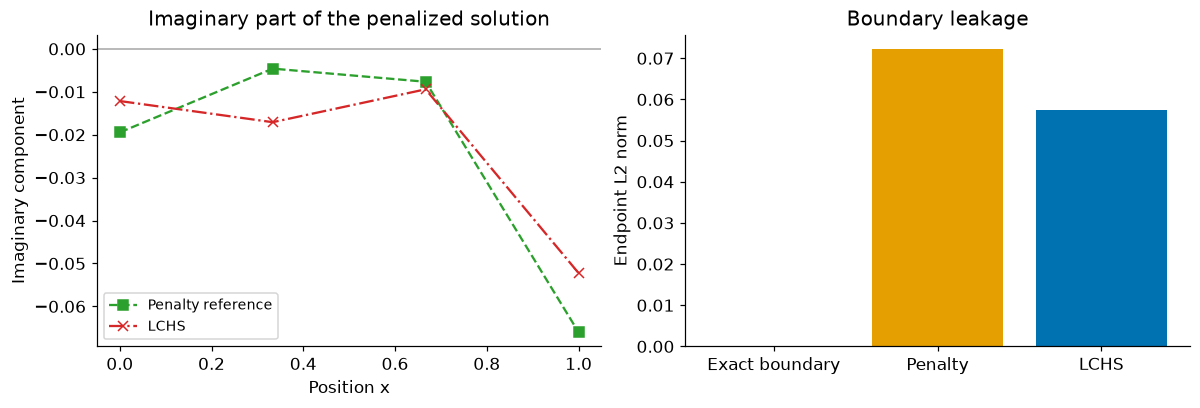

Quantity,Absolute L2 value,Kind of number
"LCHS vs. penalty reference, E_algorithm",0.0539,Measured against reference. 2.8% of the reference norm
"Penalty vs. exact-boundary reference, E_penalty",0.0727,Measured against reference. 3.8% of the reference norm
"LCHS vs. exact-boundary reference, E_combined",0.077,Measured against reference. 4.0% of the reference norm
Kernel-approximation bound,unavailable,Unavailable: the signed-binary k grid supplies none
k-quadrature bound,unavailable,Unavailable: the signed-binary k grid supplies none
Roundoff of the simulated state,unavailable,Unavailable: outside the roundoff derivation: amplitude-derived masses


In [6]:
leakage = [np.linalg.norm(values[boundary]) for values in (u_dirichlet, v_penalty, v_lchs)]

fig, axes = plt.subplots(1, 2, figsize=(10.8, 3.6), layout="constrained")
axes[0].axhline(0.0, color="0.65", linewidth=1)
axes[0].plot(coordinates, v_penalty.imag, "s--", color="C2", label="Penalty reference")  # colors of the result card
axes[0].plot(coordinates, v_lchs.imag, "x-.", color="C3", label="LCHS")
axes[0].set(xlabel="Position x", ylabel="Imaginary component", title="Imaginary part of the penalized solution")
axes[0].legend(fontsize=9)
axes[1].bar(("Exact boundary", "Penalty", "LCHS"), leakage,
            color=("#009E73", "#E69F00", "#0072B2"))
axes[1].set(ylabel="Endpoint L2 norm", title="Boundary leakage", ylim=(0, None))
plt.show()
roundoff, roundoff_reason = result.data.receipts[0].state_error()
show_table([
    ("LCHS vs. penalty reference, E_algorithm", algorithm_error,
     f"Measured against reference. {algorithm_error / np.linalg.norm(v_penalty):.1%} of the reference norm"),
    ("Penalty vs. exact-boundary reference, E_penalty", penalty_error,
     f"Measured against reference. {penalty_error / np.linalg.norm(u_dirichlet):.1%} of the reference norm"),
    ("LCHS vs. exact-boundary reference, E_combined", combined_error,
     f"Measured against reference. {combined_error / np.linalg.norm(u_dirichlet):.1%} of the reference norm"),
    ("Kernel-approximation bound", rec.kernel_approximation_bound,
     "Unavailable: the signed-binary k grid supplies none" if rec.kernel_approximation_bound is None else "Upper bound"),
    ("k-quadrature bound", rec.quadrature_bound,
     "Unavailable: the signed-binary k grid supplies none" if rec.quadrature_bound is None else "Upper bound"),
    ("Roundoff of the simulated state", roundoff,
     "Upper bound" if roundoff is not None else "Unavailable: " + roundoff_reason),
], headers=("Quantity", "Absolute L2 value", "Kind of number"))

These errors describe the four-point model. A finer grid would be needed to judge the error against a continuous rod.

**The first cell holds the settings that change these errors and the cost.** `PENALTY` sets λ, and `K_QUBITS` and `DUHAMEL_NODES` set the number of weighted branches, which the CX count grows with. This notebook runs one setting. The [LCHS introduction](lchs_linear_dynamics_intro.ipynb) compares Trotter steps against quadrature.

## 4. How large can I go?

**The local simulator sets the size limit, and `plan` and `estimate` still give the cost of larger problems.** The table lists this run's limits and its use of them.

The dense branches here exponentiate each $4\times4$ Hamiltonian classically, which suits a small verification problem.

At larger sizes, the product-formula and QSP evolution backends of `LCHS` replace them, and their cost per branch depends on the number of Pauli terms and time steps. [Planning at scale](resource_estimation_at_scale.ipynb) plans circuits far beyond any simulator.

In [7]:
limits = trace.limits
show_table([
    ("Qubits the local simulator accepts", limits.max_simulation_qubits, f"Default. This rod uses {total_qubits}"),
    ("Simulator memory cap", f"{limits.simulator_memory_mb:,} MB", "Default simulator_memory_mb"),
    ("Address qubits", len(rec.success_bits), f"{rec.physical_branches} weighted branches in {rec.padded_branches} slots"),
], headers=("Limit or use", "Value", "Meaning"))

Limit or use,Value,Meaning
Qubits the local simulator accepts,20,Default. This rod uses 10
Simulator memory cap,"1,024 MB",Default simulator_memory_mb
Address qubits,8,160 weighted branches in 256 slots


## 5. What does it assume?

**This run has no noise, and its counts are logical counts.** The simulator returns every amplitude exactly. Aer applies a noise model to sampled counts ([Local Aer](../docs/aer.md)), and [Choose a backend](../docs/backends.md) lists the other backends.

The model narrows the paper's setting in two ways.

- It is a one-dimensional rod with four grid points, where the paper's heat experiments use a two-dimensional grid.
- It applies direct LCHS to the finite penalized matrix. The paper's interaction-picture method addresses the cost of a large penalty strength, and this notebook does not test that scaling claim.

On hardware, the requested output might be an interior average or another observable, and its measurement cost would be part of the algorithm.

## 6. What NWQLib adds

- **Cost at sizes no simulator holds.** `plan` and `estimate` run without building the circuit ([Planning at scale](resource_estimation_at_scale.ipynb)).
- **A formula behind each predicted count.** `estimate` sums a gate-count formula per block ([Mathematics](../docs/mathematics.md)), and Section 2 compares the sum with the compiled circuit.
- **One argument changes the branch evolution.** `hamiltonian_evolution_backend` selects exact (`"dense_exact"`), product-formula (`"trotter"`) or QSP (`"qsp_block_encoding"`) branches, and `lchs_kernel` the kernel. The [LCHS introduction](lchs_linear_dynamics_intro.ipynb) compares kernels and quadratures.

[Why NWQLib](../docs/why_nwqlib.md) compares this workflow with other packages.

## 7. Four temperatures on a rod

The starting point is Schleich, Kharazi, Li and colleagues' [*Arbitrary Boundary Conditions and Constraints in Quantum Algorithms for Differential Equations via Penalty Projections*](https://arxiv.org/html/2506.21751v1). Section III.2.1, Eqs. (130)–(134), studies a two-dimensional heat equation.

Section II.2, Problem 7, Eq. (14), introduces the imaginary penalty $-i\lambda P_c$ used here, and Section IV, Eq. (140), restates it for the interaction-picture LCHS algorithm. This notebook takes a **one-dimensional teaching specialization** with the same penalty mechanism.

Position, time and temperature are dimensionless. $D=4$ and the source rate 298 are the values of the paper's heat experiments, which place a point source of that strength at the center element (arXiv:2506.21751v1, Section III.2.1 and the caption of Figure 5).

The paper's Figure 5 uses a $32\times32$ grid and $T=1$. On four points, with spacing $h=1/3$, the slower interior mode decays at the rate $D/h^2=36$. The rod would reach its steady state long before $T=1$, so this example stops at $T=0.005$, where $DT/h^2=0.18$.

The overview shows the default quadrature settings, and the tables show the current selection.

![Heat flow, the boundary penalty, and LCHS](generators/assets/lchs_small_overview.png)

Let $u(x,t)$ be the temperature above the cold-end temperature. The heat equation is

$$\partial_tu=D\partial_{xx}u+f.$$

The second derivative compares a point with its neighbors, so a point hotter than both neighbors loses heat. The source $f$ adds heat continuously, in temperature per unit time.

We sample positions $x_j=jh$, with $j=0,1,2,3$ and $h=1/3$. At an interior point, the finite-difference equation is

$$\dot u_j=\frac{D}{h^2}(u_{j-1}-2u_j+u_{j+1})+f_j.$$

A zero Dirichlet boundary condition means $u_0=u_3=0$ at every time, so only the two interior temperatures are unknown. Heat can leave through the cold ends, and the temperature sum inside the rod need not stay constant.

Quantity,Value,Meaning
Fixed grid points,4,Two endpoints and two interior coordinates
Diffusion coefficient D,4,Position squared per unit time
Final time T,0.005,Time from the initial condition to the requested output
Penalty strength lambda,1000,"Endpoint phase-rotation rate, in inverse-time units"
Source rate,298,Temperature per unit time at x = 0.667


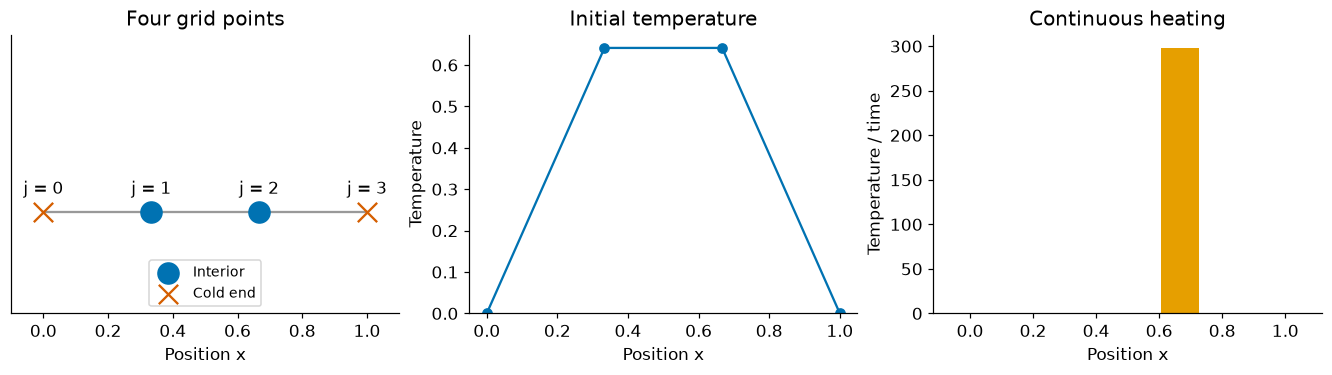

In [8]:
show_table([
    ("Fixed grid points", N, "Two endpoints and two interior coordinates"),
    ("Diffusion coefficient D", D, "Position squared per unit time"),
    ("Final time T", FINAL_TIME, "Time from the initial condition to the requested output"),
    ("Penalty strength lambda", PENALTY, "Endpoint phase-rotation rate, in inverse-time units"),
    ("Source rate", SOURCE_RATE, f"Temperature per unit time at x = {format_value(coordinates[2])}"),
], digits=6)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.3), layout="constrained")
axes[0].plot(coordinates, np.zeros(N), color="0.6", zorder=1)
axes[0].scatter(coordinates[interior], np.zeros(2), s=190, color="#0072B2", label="Interior")
axes[0].scatter(coordinates[boundary], np.zeros(2), s=160, marker="x", color="#D55E00", label="Cold end")
for j, position in enumerate(coordinates):
    axes[0].annotate(f"j = {j}", (position, 0), xytext=(0, 12),
                     textcoords="offset points", ha="center")
axes[0].set(xlabel="Position x", yticks=[], ylim=(-0.2, 0.35),
            xlim=(-0.1, 1.1), title="Four grid points")
axes[0].legend(loc="lower center", fontsize=9)
axes[1].plot(coordinates, initial, "o-", color="#0072B2")
axes[1].set(xlabel="Position x", ylabel="Temperature", title="Initial temperature", ylim=(0, None))
axes[2].bar(coordinates, source, width=0.12, color="#E69F00")
axes[2].set(xlabel="Position x", ylabel="Temperature / time", title="Continuous heating", ylim=(0, None))
plt.show()

The three panels show different quantities: the endpoints, the starting temperatures and a heating rate, whose scale cannot be compared with temperature. No grid point sits at $x=1/2$, so the heater is at $x=2/3$.

## 8. Enforcing a cold end through an imaginary penalty

Following the paper's construction (arXiv:2506.21751v1), first form a periodic Laplacian. Its last point connects back to its first, so the unconstrained geometry is a ring. Its heat generator $B_0=D\Delta_h$ has nonpositive eigenvalues.

The projector $P_c=\operatorname{diag}(1,0,0,1)$ selects the endpoints, so $P_cv$ holds exactly the values that violate a zero-endpoint constraint. The penalty approach evolves all four coordinates:

$$\dot v=(B_0-i\lambda P_c)v+f.$$

The imaginary penalty rotates phase at the endpoints. Acting alone, it multiplies an endpoint value by $e^{-i\lambda t}$, whose magnitude is 1, and does **not** damp it by $e^{-\lambda t}$.

Its rapid oscillation changes how the endpoints exchange amplitude with the interior. At finite $\lambda$, the resulting vector can be complex and can violate the exact boundary condition.

NWQLib uses $\dot v=-Av+f$, so the required input is

$$A=-B_0+i\lambda P_c=L+iH,\qquad L=-B_0\succeq0,\qquad H=\lambda P_c.$$

$L\succeq0$ means that every eigenvalue of $L$ is nonnegative. For this periodic stencil, they are $4D\sin^2(\pi m/4)/h^2$, with $m=0,1,2,3$, which gives the premise of the LCHS representation.

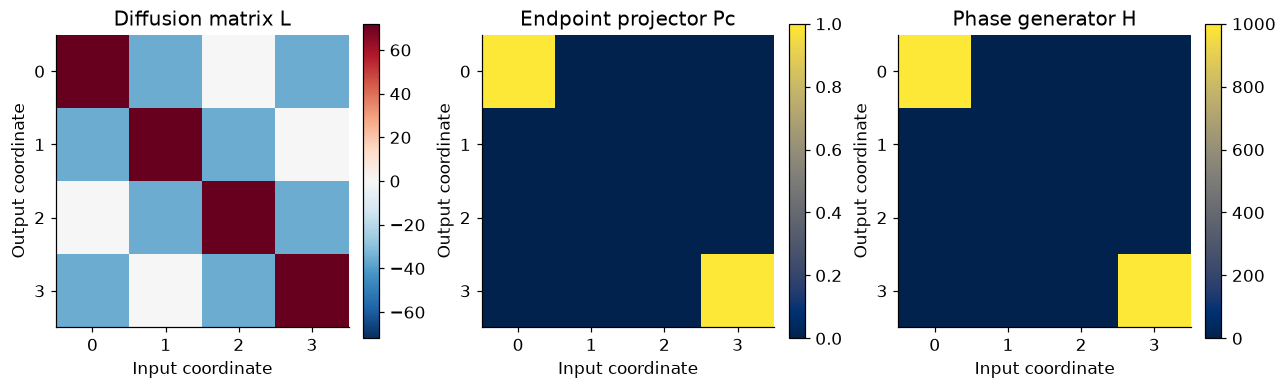

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(11.6, 3.4), layout="constrained")
for ax, matrix, title, diverging in zip(
    axes, (L, Pc, H), ("Diffusion matrix L", "Endpoint projector Pc", "Phase generator H"),
    (True, False, False), strict=True,
):
    scale = float(np.max(np.abs(matrix)))
    im = ax.imshow(matrix, cmap="RdBu_r" if diverging else "cividis",
                   vmin=-scale if diverging else 0.0, vmax=scale)
    ax.set(xticks=range(N), yticks=range(N), xlabel="Input coordinate", ylabel="Output coordinate", title=title)
    fig.colorbar(im, ax=ax)
plt.show()

The diffusion matrix couples neighbors, and the projector selects two coordinates without coupling. Increasing $\lambda$ changes only $H$. The periodic link between coordinates 0 and 3 belongs to the unconstrained operator, and the exact-boundary reference removes it with the endpoints.

## 9. Representing diffusion with unitary branches

Unitary evolution preserves the norm of a state, while a heat equation changes the norm of its temperature vector. LCHS writes the nonunitary evolution as an integral of unitary evolutions, for $L\succeq0$ and a kernel $f$:

$$e^{-At}=\int_{\mathbb R}\frac{f(k)}{1-ik}e^{-i(kL+H)t}\,dk$$

(An, Childs and Lin, arXiv:2312.03916v2, Eqs. (6)–(7)). A finite quadrature over $k$ gives

$$e^{-At}\approx\sum_a c_a e^{-i(k_aL+H)t}.$$

Each $k_aL+H$ is Hermitian and generates a unitary branch, labelled by a branch-address register. Preparing the weights on that register (PREP), applying the branch each address selects (SELECT) and reversing PREP produces the sum in a designated success subspace.

`Solution()` returns the physical vector with its overall scale and phase, which temperature needs. The constant heater contributes throughout the interval, according to Duhamel's formula:

$$v(T)=e^{-AT}v(0)+\int_0^T e^{-A(T-s)}f\,ds.$$

**The explicit quadrature of the first code cell fixes this approximation.** `approximation_tolerance=0.01` does not refine that grid and does not certify a 1% error in the final temperature. The signed-binary grid carries no kernel-approximation or k-quadrature bound, so Section 3 reports both as unavailable.

The kernel exponent $\beta=0.9$ lies above the range [0.7, 0.8] that An, Childs and Lin report as numerically best for truncation (arXiv:2312.03916v2, Sec. 2.2). Section 3 measures how accurately this particular construction solves its penalized equation.

## Appendix

The appendix displays numbers to six significant figures. A click on a summary line opens each collapsed table.

### A. Input scales and comparison details

Three combinations describe the inputs. $DT/h^2$ compares the interval with diffusion across one grid spacing, and $\lambda T$ is the endpoint phase rotation from the penalty alone. $T\|f\|_2$ is the source norm accumulated without evolution, to set beside $\|v(0)\|_2$.

In [10]:
show_table([
    ("Diffusion scale D T / h²", D * FINAL_TIME / h**2, "Time interval measured against diffusion across one grid spacing"),
    ("Penalty phase lambda T", PENALTY * FINAL_TIME, "Endpoint phase rotation in radians from the penalty alone"),
    ("Source injection T ||f||₂", FINAL_TIME * np.linalg.norm(source), "Temperature-vector norm added over the interval if evolution is omitted"),
    ("Initial temperature norm", np.linalg.norm(initial), "Initial temperature scale for comparison with the source injection"),
], digits=6)

show_table([
    ("Triangle-inequality upper sum", algorithm_error + penalty_error, "Sum of the two measured components, not a continuum-error certificate"),
    ("Exact-boundary leakage", leakage[0], "Endpoint L2 norm in the exact-boundary reference"),
    ("Penalty leakage", leakage[1], "Endpoint L2 norm in the penalty reference"),
    ("LCHS leakage", leakage[2], "Endpoint L2 norm in the returned physical vector"),
], digits=6, details="Error sum and boundary leakage")
show_table([(coordinates[j], u_dirichlet[j], v_penalty[j].real, v_penalty[j].imag,
             v_lchs[j].real, v_lchs[j].imag) for j in range(N)],
           headers=("Position x", "Exact-boundary temperature", "Penalty real", "Penalty imaginary", "LCHS real", "LCHS imaginary"),
           digits=6, details="Temperatures at each grid point")

Quantity,Value,Meaning
Diffusion scale D T / h²,0.18,Time interval measured against diffusion across one grid spacing
Penalty phase lambda T,5,Endpoint phase rotation in radians from the penalty alone
Source injection T ||f||₂,1.49,Temperature-vector norm added over the interval if evolution is omitted
Initial temperature norm,0.906766,Initial temperature scale for comparison with the source injection


Quantity,Value,Meaning
Triangle-inequality upper sum,0.126659,"Sum of the two measured components, not a continuum-error certificate"
Exact-boundary leakage,0,Endpoint L2 norm in the exact-boundary reference
Penalty leakage,0.072122,Endpoint L2 norm in the penalty reference
LCHS leakage,0.0573371,Endpoint L2 norm in the returned physical vector


Position x,Exact-boundary temperature,Penalty real,Penalty imaginary,LCHS real,LCHS imaginary
0,0,-0.0192101,-0.0194674,-0.0144118,-0.012164
0.333333,0.641704,0.642394,-0.00461267,0.607845,-0.0170936
0.666667,1.79301,1.79537,-0.0076727,1.75973,-0.009433
1,0,-0.00976401,-0.066017,-0.014267,-0.0522335


### B. Weighted branches, normalization and resources

A source contribution inserted at time $s$ evolves for the remaining time $T-s$. `K_QUBITS` sets the size of the signed-binary $k$ grid, and `DUHAMEL_NODES` the number of Gauss nodes for the source-time integral.

Each branch uses a $4\times4$ dense matrix exponential. `dense_exact` names that branch recipe, not an exact solution of the full LCHS integral, because finite $k$ range, finite quadrature and floating-point circuit construction still introduce error.

With a nonzero initial state, $M$ selected $k$ nodes and $J$ source-time nodes give $M(1+J)$ weighted branches. The address space is padded to a power of two, and two system qubits encode the four-point geometry.

In [11]:
show_table([
    ("System qubits", len(rec.system_bits), f"Encode {rec.dimension} physical coordinates"),
    ("Address qubits", len(rec.success_bits), "Label the initial-state and source branches"),
    ("Total qubits", total_qubits, "All system and address qubits in this construction"),
    ("Weighted branches", rec.physical_branches, "Selected initial-state and source terms, before address padding"),
    ("Address slots", rec.padded_branches, "Power-of-two address space, including unused slots"),
], digits=6, details="Qubits and weighted branches")

Quantity,Value,Meaning
System qubits,2,Encode 4 physical coordinates
Address qubits,8,Label the initial-state and source branches
Total qubits,10,All system and address qubits in this construction
Weighted branches,160,"Selected initial-state and source terms, before address padding"
Address slots,256,"Power-of-two address space, including unused slots"


A coefficient $c_a$ has a magnitude and a phase. PREP assigns amplitude $\sqrt{|c_a|/\alpha_k}$ to its address, and SELECT supplies the phase. The one-norm $\alpha_k=\sum_a|c_a|$ normalizes that preparation and is neither the norm of the solution nor its error.

The cell reads the base propagator's coefficients through NWQLib's public coefficient interface, with the same $A$, $T$, kernel and $k$ grid. The source construction multiplies them by the initial-vector norm or by a Gauss weight times the source norm. With zero PSD shift, the card's α is

$$\alpha_{\rm source}=\alpha_k\left(\|v(0)\|_2+\|f\|_2\sum_\ell w_\ell\right).$$

The Gauss weights sum to $T$, and each source branch evolves for $T-s_\ell$. The cell compares this normalization with the Plan's and shows the PSD support, any shift and the two component bounds, where `unavailable` means the construction has none.

Quantity,Value,Meaning
Kernel,near_optimal_eq7,Weights in the Hamiltonian integral
Kernel exponent beta,0.9,Dimensionless kernel-shape parameter
k quadrature,signed_binary_uniform,"32 nodes, spacing 0.5, from -8 to 7.5"
Base coefficient one-norm,1.76793,"Sum of coefficient magnitudes, dimensionless"
Source-weighted normalization,4.23732,"From the initial norm and source-time weights, in temperature units"
Selected normalization,4.23732,"Normalization used by this source Plan, in temperature units"
Initial-vector norm,0.906766,L2 norm in temperature units
Source-vector norm,298,L2 norm in temperature per unit time
Physical recovery scale,4.23732,Converts the success amplitudes to the physical vector
PSD support,numerical,Numerical support for nonnegative eigenvalues of L


Address,k,Real coefficient,Imaginary coefficient,Magnitude
0,0,0.189199,0,0.189199
1,0.5,0.167393,0.00260493,0.167413
2,1,0.128033,-0.0130756,0.128699
3,1.5,0.0918653,-0.0316749,0.0971727
4,2,0.0608033,-0.0438658,0.074975
5,2.5,0.0345279,-0.0483223,0.0593904
6,3,0.0132088,-0.0462918,0.0481394
7,3.5,-0.00292287,-0.0396536,0.0397612
8,4,-0.0138967,-0.0303131,0.0333467
9,4.5,-0.0200847,-0.0199639,0.0283188


Insertion time s,Gauss weight w [time],Remaining evolution time T − s
0.000347159,0.000869637,0.00465284
0.00165005,0.00163036,0.00334995
0.00334995,0.00163036,0.00165005
0.00465284,0.000869637,0.000347159


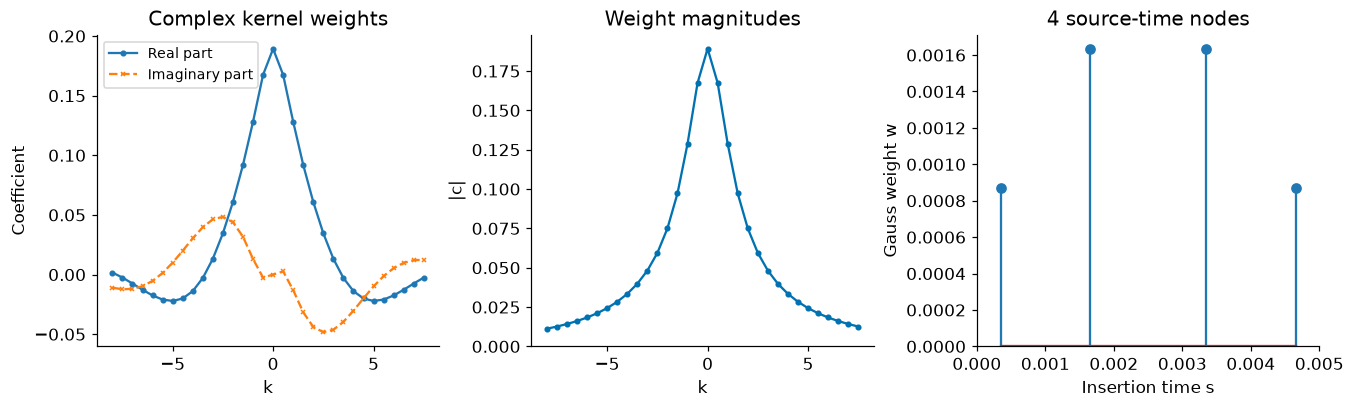

In [12]:
from nwqlib.algorithms.lchs import resolve_lchs_coefficient_plan

base_coefficients = resolve_lchs_coefficient_plan(
    LinearDynamics(A=A, initial_state=initial, time=FINAL_TIME),
    lchs_kernel=method.lchs_kernel,
    k_quadrature=method.k_quadrature,
    approximation_tolerance=method.approximation_tolerance,
)
k_nodes = np.asarray(base_coefficients.nodes)
k_coefficients = np.asarray(base_coefficients.coefficients)
source_nodes = np.asarray(rec.source_nodes)
source_weights = np.asarray(rec.source_weights)
order = np.argsort(k_nodes)
ordered_nodes = k_nodes[order]
grid_spacing = ordered_nodes[1] - ordered_nodes[0]
alpha_from_source_weights = base_coefficients.coefficient_l1_norm * (
    np.linalg.norm(initial) + np.linalg.norm(source) * source_weights.sum()
)
show_table([
    ("Kernel", base_coefficients.resolved_lchs_kernel.implementation, "Weights in the Hamiltonian integral"),
    ("Kernel exponent beta", base_coefficients.resolved_lchs_kernel.parameters["beta"], "Dimensionless kernel-shape parameter"),
    ("k quadrature", base_coefficients.resolved_k_quadrature.implementation,
     f"{len(k_nodes)} nodes, spacing {format_value(grid_spacing, 6)}, from {format_value(ordered_nodes[0], 6)} to {format_value(ordered_nodes[-1], 6)}"),
    ("Base coefficient one-norm", base_coefficients.coefficient_l1_norm, "Sum of coefficient magnitudes, dimensionless"),
    ("Source-weighted normalization", alpha_from_source_weights, "From the initial norm and source-time weights, in temperature units"),
    ("Selected normalization", rec.coefficient_l1_norm, "Normalization used by this source Plan, in temperature units"),
    ("Initial-vector norm", rec.initial_scale.as_float(), "L2 norm in temperature units"),
    ("Source-vector norm", rec.source_scale.as_float(), "L2 norm in temperature per unit time"),
    ("Physical recovery scale", rec.recovery.as_float(), "Converts the success amplitudes to the physical vector"),
    ("PSD support", rec.psd_premise, "Numerical support for nonnegative eigenvalues of L"),
    ("PSD shift", rec.psd_shift, "Added decay rate, in inverse-time units"),
    ("L norm", rec.l_norm, "Spectral norm of the diffusion component, in inverse-time units"),
    ("Kernel-approximation bound", rec.kernel_approximation_bound, "Propagator component bound, not total temperature error"),
    ("k-quadrature bound", rec.quadrature_bound, "Propagator component bound, unavailable when the selected rule supplies none"),
], digits=6, details="Kernel, quadrature and normalization")
show_table([(address, node, coefficient.real, coefficient.imag, abs(coefficient))
            for address, (node, coefficient) in enumerate(zip(k_nodes, k_coefficients, strict=True))],
           headers=("Address", "k", "Real coefficient", "Imaginary coefficient", "Magnitude"),
           digits=6, details=f"Coefficients of the {len(k_nodes)} k nodes")
show_table([(node, weight, FINAL_TIME - node) for node, weight in zip(source_nodes, source_weights, strict=True)],
           headers=("Insertion time s", "Gauss weight w [time]", "Remaining evolution time T − s"),
           digits=6, details="Source-time nodes and weights")

fig, axes = plt.subplots(1, 3, figsize=(12.2, 3.6), layout="constrained")
axes[0].plot(k_nodes[order], k_coefficients.real[order], "o-", markersize=3, label="Real part")
axes[0].plot(k_nodes[order], k_coefficients.imag[order], "x--", markersize=3, label="Imaginary part")
axes[0].set(xlabel="k", ylabel="Coefficient", title="Complex kernel weights")
axes[0].legend(fontsize=9)
axes[1].plot(k_nodes[order], np.abs(k_coefficients[order]), "o-", markersize=3, color="#0072B2")
axes[1].set(xlabel="k", ylabel="|c|", title="Weight magnitudes", ylim=(0, None))
axes[2].stem(source_nodes, source_weights)
axes[2].set(xlabel="Insertion time s", ylabel="Gauss weight w", title=f"{len(source_nodes)} source-time nodes", xlim=(0, FINAL_TIME), ylim=(0, None))
plt.show()

### C. The resource estimate in the default logical basis

Each row states the population it counts, such as the simultaneous live footprint for width and memory or the dynamic workload for gate counts.

The CX count of Section 2 belongs to the `cx` resource basis. The default logical basis has no two-qubit law for SELECT or the coefficient preparation, so it reports gate counts as unavailable.

In [13]:
resources = estimate(selected)
resource_lookup = {(item.metric, item.location): item for item in resources.quantities}
resource_rows = []
for metric, location, label, meaning in (
    ("logical_width", "logical_device", "Logical width", "All qubits in the selected construction"),
    ("known_memory", "host", "Known host memory", "Declared arrays and payloads, not process peak RSS or all native workspace"),
    ("construction_work", None, "Planned construction work", "Selected-definition and binding work proxy, not measured CPU time"),
    ("operations", None, "Planned operation count", "Unknown unless the selected resource laws provide a value"),
    ("two_qubit", None, "Planned two-qubit gates", "Unknown does not mean zero gates"),
    ("logical_depth", None, "Planned circuit depth", "Depth is separate from circuit width"),
):
    quantity = resource_lookup[(metric, location)]
    fact = quantity.fact
    value = fact.symbol.name if fact.availability == "symbolic" else fact_value(fact)
    scope = f"{meaning}. {quantity.population}. Basis: {quantity.basis}. {quantity.interpretation.replace('_', ' ')}."
    if fact.reason:
        scope += " " + fact.reason
    if fact.assumptions:
        scope += " Conditions: " + ". ".join(fact.assumptions)
    resource_rows.append((label, value, fact.unit.symbol, scope))
show_table(resource_rows, headers=("Resource", "Value", "Unit", "Population and limits"), digits=6,
           details="Resource estimate in the default logical basis")

Resource,Value,Unit,Population and limits
Logical width,10,count,All qubits in the selected construction. simultaneous live footprint. Basis: selected_logical. exact.
Known host memory,"111,646,720",byte,"Declared arrays and payloads, not process peak RSS or all native workspace. simultaneous live footprint. Basis: selected_logical. exact."
Planned construction work,"20,217,728",count,"Selected-definition and binding work proxy, not measured CPU time. potential unique selected definitions and host bindings; excludes dynamic replay and numerical host execution. Basis: selected_logical. upper bound."
Planned operation count,unavailable,count,Unknown unless the selected resource laws provide a value. dynamic workload. Basis: selected_logical. unavailable. coefficient_inverse: no selected operations law/decomposition; coefficient_prep: no selected operations law/decomposition; lchs_select: no selected operations law/decomposition
Planned two-qubit gates,unavailable,count,Unknown does not mean zero gates. dynamic workload. Basis: selected_logical. unavailable. coefficient_inverse: no selected two_qubit law/decomposition; coefficient_prep: no selected two_qubit law/decomposition; lchs_select: no selected two_qubit law/decomposition
Planned circuit depth,unavailable,count,Depth is separate from circuit width. dynamic workload. Basis: selected_logical. unavailable. coefficient_inverse: no selected logical_depth law/decomposition; coefficient_prep: no selected logical_depth law/decomposition; lchs_select: no selected logical_depth law/decomposition


### D. A reference check attached to the result

`result.verify` records an explicit reference comparison with the result. For this constant source, `closed_form` evaluates $e^{-AT}v(0)+\int_0^T e^{-As}\,ds\,f$ from one exponential of the $5\times5$ augmented matrix of Section 3, without a linear solve.

It uses the same exponential as the penalty reference, so the two discrepancies agree to rounding and the check adds a record, not an independent reference. It is floating-point evidence without a pass threshold, and it does not turn the quadrature or continuum approximation into a total-error bound.

In [14]:
from nwqlib.algorithms.lchs import LCHSVerification

checks = LCHSVerification(reference="closed_form", metric="absolute_l2")
verification_receipt, verification_facts = result.verify(checks=checks)
verification_arguments = {
    argument.parameter: argument.value if isinstance(argument.value, int) else argument.value.value
    for application in verification_receipt.applications for argument in application.arguments
}
verification_metrics = {item.fact.quantity: fact_value(item.fact)
                        for application in verification_receipt.applications for item in application.facts}
show_table([
    ("Check", "Constant-source closed form", "One 5 × 5 augmented matrix exponential, without a linear solve"),
    ("Compared quantity", "Absolute complex L2 error", "Physical coordinates, including magnitude and phase"),
    ("Recorded discrepancy", fact_value(verification_facts[0].fact), "Difference between the returned vector and the closed form"),
    ("Section 3 discrepancy", algorithm_error, "Same augmented exponential as this check, so the two values agree to rounding"),
    ("Reference norm", verification_metrics[checks.name + ".reference_norm"], "Closed-form solution L2 norm, in temperature units"),
    ("Conclusion scope", "Finite penalized equation", "Floating-point comparison without a pass threshold or continuum-error bound"),
    ("Matrix exponentials completed", verification_arguments["expm_completed"], "Actual new reference exponentials recorded in this check"),
    ("Matrix-vector products completed", verification_arguments["matvec_completed"], "Actual products of the new exponential with the initial vector"),
], digits=6)

Quantity,Value,Meaning
Check,Constant-source closed form,"One 5 × 5 augmented matrix exponential, without a linear solve"
Compared quantity,Absolute complex L2 error,"Physical coordinates, including magnitude and phase"
Recorded discrepancy,0.0539419,Difference between the returned vector and the closed form
Section 3 discrepancy,0.0539419,"Same augmented exponential as this check, so the two values agree to rounding"
Reference norm,1.90822,"Closed-form solution L2 norm, in temperature units"
Conclusion scope,Finite penalized equation,Floating-point comparison without a pass threshold or continuum-error bound
Matrix exponentials completed,1,Actual new reference exponentials recorded in this check
Matrix-vector products completed,1,Actual products of the new exponential with the initial vector


### E. Which run produced these temperatures

The result keeps the plan, the simulator run and the data it returned, so a later comparison can tell a changed equation or approximation from a changed run.

The identifiers and recorded versions are collapsed. Setting `REPORT_PATH` exports the inputs, references, LCHS output and complete records as JSON, without a circuit or statevector.

In [15]:
import json
from pathlib import Path

REPORT_PATH = None  # Set Path("lchs_scientific_report.json") to export the inputs, references and records.

report = result.report()
show_table([
    ("Simulator", [receipt["target"]["name"] for receipt in report["receipts"]], "Target that ran the circuit"),
    ("Runs and outcome", [event["status"] for event in report["trace"]["events"]], "A completed run does not by itself establish accuracy"),
    ("Circuit instructions", [receipt["native_operations"] for receipt in report["receipts"]], "Instructions of the prepared circuit, not a CX count"),
])
show_table([(entry["name"], entry["version"]) for receipt in report["receipts"] for entry in receipt["environment"]],
           headers=("Package", "Version recorded with the circuit"), details="Recorded versions")
show_table([
    ("Plan identifier", result.plan_id, "The equation, selected method, and requested output"),
    ("Result identifier", result.content_id, "The solution and the data it used"),
    ("Run identifier", report["trace"]["run_id"], "The recorded simulator run"),
    ("Reference-check identifier", verification_receipt.content_id, "The closed-form comparison of Appendix D and its options"),
], details="Identifiers")
if REPORT_PATH is not None:
    scientific_record = {
        "nwqlib_report": report,
        "input": {"A_real": A.real.tolist(), "A_imag": A.imag.tolist(),
                  "initial": initial.tolist(), "source": source.tolist(), "time": FINAL_TIME},
        "coefficient_model": base_coefficients.record(),
        "base_k_nodes": k_nodes.tolist(),
        "base_coefficients_real": k_coefficients.real.tolist(),
        "base_coefficients_imag": k_coefficients.imag.tolist(),
        "references": {"penalty_real": v_penalty.real.tolist(), "penalty_imag": v_penalty.imag.tolist(),
                       "dirichlet": u_dirichlet.tolist()},
        "lchs_output": {"real": v_lchs.real.tolist(), "imag": v_lchs.imag.tolist()},
        "errors": {"algorithm_l2": float(algorithm_error), "penalty_l2": float(penalty_error),
                   "combined_l2": float(combined_error)},
        "verification_receipt": verification_receipt.model_dump(mode="json"),
        "verification_facts": [fact.model_dump(mode="json") for fact in verification_facts],
    }
    Path(REPORT_PATH).write_text(json.dumps(scientific_record, indent=2, ensure_ascii=False, allow_nan=False), encoding="utf-8")

Quantity,Value,Meaning
Simulator,aer_statevector,Target that ran the circuit
Runs and outcome,completed,A completed run does not by itself establish accuracy
Circuit instructions,"725,600","Instructions of the prepared circuit, not a CX count"


Package,Version recorded with the circuit
nwqlib,0.99.1
numpy,2.5.2
qiskit,2.5.2
qiskit-aer,0.17.2
python,3.12.14


Quantity,Value,Meaning
Plan identifier,sha256:38ec005aef82e2fbc969fbfc675160a04a0a6978ae49f65f25e049c5ffd47e6c,"The equation, selected method, and requested output"
Result identifier,sha256:de5fe6668506edf346c7ede1285792268a2afba247438ce7b7a4b2f4ecac981c,The solution and the data it used
Run identifier,f8606d16-4569-4ba4-8410-66e2e2faec3a,The recorded simulator run
Reference-check identifier,sha256:13f591510f193ab7facc8ee15b19389f4a52ca136199201edd7bdf91a1f5cbf5,The closed-form comparison of Appendix D and its options
